In [ ]:
#| default_exp module_functions_ex

In [ ]:
#| hide

import plotly.io as pio

In [ ]:
#| hide
pio.renderers.default = "png"

In [ ]:
#| exporti

x_coor: list[int] = [
    127, 218, 249, 286, 338, 383, 422, 491, 537, 595, \
     86, 127, 167, 221, 269, 311, 365, 397, 462, 505, 560, 622, \
     46, 185, 226, 263, 326, 426, 484, \
     39,  86, 123, 187, 265, \
     30,  78, 132, 184, 246, 405, 470, 529, 592, \
     40,  86, 153, 208, 248, 316, 368, 417, 494, 561, \
     42,  82, 156, 186, 254, 327, 372, 469, 514, 599, \
     44,  91, 146, 215, 277, 350, 413, 490, 578, \
     62, 154, 302, 473, 303
]    # 60: 479 -> 469  405 -> 350  470 -> 450

y_coor: list[int] = [
     28,  19,  23,  19,  20,  22,  21,  19,  14,  13, \
     48,  51,  54,  52,  48,  46,  40,  51,  43,  48,  42,  50, \
     75,  83,  76,  72,  59,  64,  66, \
    105, 103,  98, 110,  96, \
    130, 136, 137, 144, 124, 138, 141, 140, 137, \
    173, 169, 166, 176, 166, 185, 172, 172, 177, 180, \
    202, 211, 217, 216, 216, 217, 224, 216, 221, 220, \
    247, 249, 252, 260, 249, 260, 263, 260, 282, \
    426, 452, 411, 412, 478
]

# Module-Level Functions
> Module-level examples illustrate the module-level functions in action, guiding the user from simpler to more complex workflows. Each subsection mirrors its corresponding *Module‑Level Function*, showing how higher-level analytical operations build on the core API to form complete, reusable workflows.

> Most examples address the ML workflow for classification. 
> The most basic workflow is demonstrated in four steps:
>
>1. obtain input data using [FhEmb library](./api.ipynb),
>2. prepare the data,
>3. split and scale,
>4. train and test a classifier.
>5. diagnose via a projection into a low-dimensional space.

::: {.callout-note title="Classification problem" label="classif_problem"}
Accuracy quantifies how well a binary classifier distinguishes between two classes. We define a class as a group of synchronized time‑series, which belong to the same segment of the underlying `Datasource` object. High accuracy indicates that the embeddings preserve class‑specific temporal structure strongly enough for a classifier to separate the two groups.
:::

## 1. Obtain Input Data {#obtain_input_data}
> The input data here is the previously constructed `EmbeddingCollection` object `emb_prj_decomp_rec1`. 

::: {.callout-note title="EmbeddingCollection"}
The `EmbeddingCollection` is constructed in the *Wdecomposition Objects* subsection. It already provides a sophisticated, handcrafted embedding of the data.
:::

In [ ]:
#| eval: false
#| exports

from nbdev_fhemb.wreconstruction_ex import emb_prj_decomp_rec1

## 2. Prepare Data
>1. Create a data matrix with [ 2N ] rows.
>    - Rows 1…N store the embedding‑start time series.
>    - Rows N+1…2N store the embedding‑end time series.
>    Each “vector” is understood to be a time‑series sample, not a static feature vector.
>
>2. Create a binary vector with [2N] class labels 

In [ ]:
#| eval: false
#| exports
from fhemb.utils.cutils import prepare_data, split_scale_data, calc_accuracies

In [ ]:
#| eval: false
#| exports

Xdm, ydm = prepare_data(                          # ensure deduplication, NaN handling, class balancing 
    emb_prj_decomp_rec1.get_df_ts_subjs('p80')['percentiles_ts'].iloc[:250].T, 
    emb_prj_decomp_rec1.get_df_ts_subjs('p80')['percentiles_ts'].iloc[750:].T
)

 [DEBUG] embedding.__getattr__: Accessing attribute/method 'get_df_ts_subjs' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomponents_ts', 'features_ts']
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for p80
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for p80
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for p80
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for p80
 [DEBUG] embedding.__getattr__: Accessing attribute/method 'get_df_ts_subjs' across embeddings: found in ['percentiles_ts', 'binheights_ts', 'pcomponents_ts', 'features_ts']
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for p80
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for p80
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for p80
 [DEBUG] embedding.get_df_ts_subjs: Using already calculated values for p80


## 3. Split and Scale
>1. Split data into train and test sets
>    - Use 30% of the data for testing
>    - Use 70% of the data for training    
>2. Scale data
>    - Use mean-variance scaling

In [ ]:
#| eval: false
#| exports

X_train, X_test, y_train, y_test, _ = split_scale_data(
    Xdm, 
    ydm,
    test_size=0.3, 
    random_state=0, 
    normalize='meanvar'
)

/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


## 4. Train and Test Classifiers
>Usually a single function includes the following steps:
>
>1. Fit a classifier
>2. Make predictions using the classifier
>3. Evaluate the classifier

::: {.callout-note title="Latent space"}
Training and testing a classifier may induce a new implicit representation space. Examples include:

- Kernel‑induced feature space in *SVMs*, created during `calc_accuracies`.
- Latent manifold learned by *VAE/DVAE* models in `DVAE.VAEClassifier.fit`.
- Shapelet‑distance space used by shapelet‑based classifiers in `calc_shapelet`.
- Prototype space formed by prototypical networks in `calc_prototype_accuracy`.
- Pairwise‑relation space constructed in relation‑based approaches in `calc_and_save_pr_accuracy`.
:::

In [ ]:
#| eval: false
calc_accuracies(
    X_train.squeeze(),   # squeeze to remove singleton dimension: (44, 250, 1) -> (44, 250) where 250 is the number of features
    X_test.squeeze(),    # where the features correspond to timesteps 
    y_train,             # train labels
    y_test               # test labels
)

 [INFO] cutils.calc_accuracies: Accuracy of KNN with cosine metric: 0.65
 [INFO] cutils.calc_accuracies: Accuracy of KNN with nan_euclidean metric: 0.65
 [INFO] cutils.calc_accuracies: Accuracy of KNN with l1 metric: 0.55
 [INFO] cutils.calc_accuracies: Accuracy of KNN with minkowski metric: 0.80
 [INFO] cutils.calc_accuracies: Accuracy of KNN with euclidean metric: 0.65
 [WARNING] cutils.calc_accuracies: Error with metric precomputed: Negative values in data passed to X.
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
 [INFO] cutils.calc_accuracies: Accuracy of rotf: 0.65
 [INFO] cutils.cal

{'knn_cosine': 0.65,
 'knn_nan_euclidean': 0.65,
 'knn_l1': 0.55,
 'knn_minkowski': 0.8,
 'knn_euclidean': 0.65,
 'rotf': 0.65,
 'randf': 0.55,
 'svm_rbf': 0.7,
 'svm_sigmoid': 0.7,
 'svm_poly': 0.6,
 'svm_linear': 0.7,
 'shapelet_rotationforest': 0.7}

## 5. Diagnose via Dimensionality Reduction

### Projection of the input space into a low-dimensional space

#### UMAP projection

In [ ]:
#| eval: false

from sklearn.manifold import TSNE
from umap import UMAP
from sklearn.decomposition import PCA

In [ ]:
#| eval: false

umap=UMAP(n_components=3, random_state=0)
reduced_umap=umap.fit_transform(Xdm)

/Users/radned/.pyenv/versions/p311.fhemb/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
#| echo: false

import matplotlib.pyplot as plt

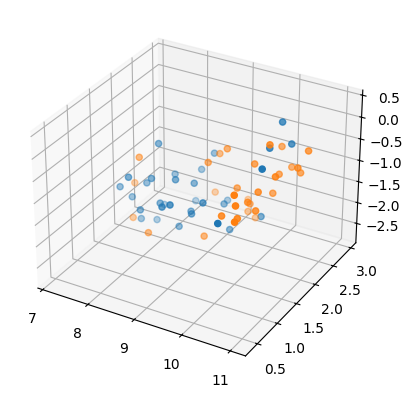

In [ ]:
#| eval: false

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(reduced_umap[ydm==0, 0], reduced_umap[ydm==0, 1], reduced_umap[ydm==0, 2])
ax.scatter(reduced_umap[ydm==1, 0], reduced_umap[ydm==1, 1], reduced_umap[ydm==1, 2])
plt.show()

#### PCA projection

In [ ]:
#| eval: false

pca=PCA(n_components=3, random_state=0)
reduced_pca=pca.fit_transform(Xdm.squeeze())

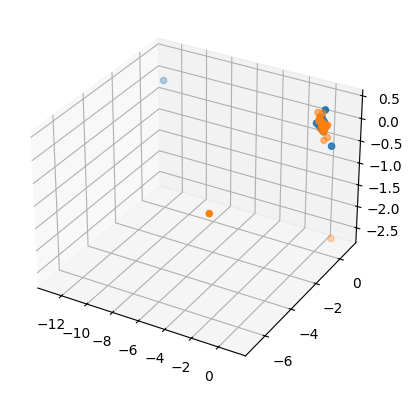

In [ ]:
#| eval: false

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(reduced_pca[ydm==0, 0], reduced_pca[ydm==0, 1], reduced_pca[ydm==0, 2])
ax.scatter(reduced_pca[ydm==1, 0], reduced_pca[ydm==1, 1], reduced_pca[ydm==1, 2])
plt.show()

::: {.callout-tip title="Pairwise Relation Embedding"}
When the latent space of a classifier is accessible, one can construct a [pairwise relation embedding](./pr_emb.ipynb) by computing all pairwise distances or similarities among samples. This enables [pairwise‑relation geometry](./pr_geometry.ipynb) diagnostic that remains stable across training runs and reveals structural properties of the learned representation.
:::

### Projection of a pairwise relation embedding of the input space into a low-dimensional space

In [ ]:
#| eval: false

from fhemb.utils.cutils import plot_pr_projection

 [DEBUG] cutils.calc_pairwise_relation: Using distance correlation
 [DEBUG] cutils.calc_pr_matrix: Computing pairwise relation matrix for symmetric data
Computing distances: 100%|██████████| 2080/2080 [00:00<00:00, 5671.47it/s]
 [WARNING] cutils.plot_pr_projection: PCA on distance-correlation matrices behaves like kernel PCA. Consider MDS or TSNE for distance-based projections.


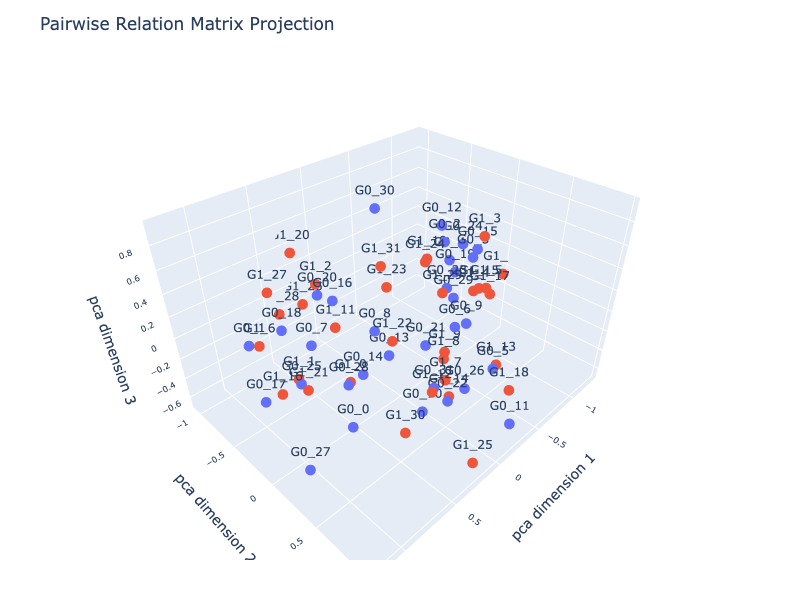

In [ ]:
#| eval: false

plot_pr_projection(
    Xdm[ydm==0],
    Xdm[ydm==1],                 # data matrices for two groups 
    alignment_type='dcor',       # distance correlation by Székely, Rizzo, and Bakirov (2007)            
    projection='pca',            # projection method for dimensionality reduction ('pca', 'tsne', 'mds', 'umap') 
    transformation='minmax',     # to transform distances into similarities for PCA
    normalize='l1',              # normalization method for distance matrix
    n_jobs=8,                    # number of jobs for parallelization
    dimensions=3,                # number of dimensions of the projection
)

In [ ]:
#| hide
#| eval: false

from fhemb.piece import Piece

In [ ]:
#| eval: false
#| hide

fftrio_segment0 = (14200, 15200)
fftrio_segment1 = (15200, 16200)

In [ ]:
#| eval: false
#| hide

fftrio0 = Piece(
    time_interval=fftrio_segment0, 
    title="Don Giovanni", 
    subjs=[(40, 44), (47,52), 53, 54, (56, 71), (73, 75)]
)

 [DEBUG] mixins.wrapper: wrapper of process_subjects called with subjs=[(40, 44), (47, 52), 53, 54, (56, 71), (73, 75)], args=() and kwargs={'time_interval': (14200, 15200), 'title': 'Don Giovanni'}
 [DEBUG] mixins.wrapper: Calling: get_piece_attribute_values with title=Don Giovanni and atributes=['number_of_subjects']
 [DEBUG] mixins.wrapper: to get subjects_int from 'number_of_subjects' record in performance_library
 [DEBUG] mixins.wrapper: Calling: __init__ with subjs=[40, 41, 42, 43, 44, 47, 48, 49, 50, 51, 52, 53, 54, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 73, 74, 75] and args=() and kwargs={'time_interval': (14200, 15200), 'title': 'Don Giovanni'}
 [DEBUG] piece.__init__: Processed subjects: [40, 41, 42, 43, 44, 47, 48, 49, 50, 51, 52, 53, 54, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 73, 74, 75]
 [DEBUG] piece.__init__: Compact numeric subjects: [(40, 44), (47, 54), (56, 71), (73, 75)]


In [ ]:
#| eval: false
#| hide

fftrio1 = Piece(
    time_interval=fftrio_segment1,
    title="Don Giovanni", 
    subjs=(40,76)
)

 [DEBUG] mixins.wrapper: wrapper of process_subjects called with subjs=(40, 76), args=() and kwargs={'time_interval': (15200, 16200), 'title': 'Don Giovanni'}
 [DEBUG] mixins.wrapper: Calling: get_piece_attribute_values with title=Don Giovanni and atributes=['number_of_subjects']
 [DEBUG] mixins.wrapper: to get subjects_int from 'number_of_subjects' record in performance_library
 [DEBUG] mixins.wrapper: Calling: __init__ with subjs=[40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76] and args=() and kwargs={'time_interval': (15200, 16200), 'title': 'Don Giovanni'}
 [DEBUG] piece.__init__: Processed subjects: [40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76]
 [DEBUG] piece.__init__: Compact numeric subjects: [(40, 76)]


In [ ]:
#| eval: false
#| hide

from fhemb.utils.factories import wfactory

In [ ]:
#| eval: false
#| hide
from fhemb.config.settings import ALL_PERCENTILES, ALL_PCOMPONENTS

In [ ]:
#| eval: false
#| hide

from nbdev_fhemb.datasource_ex import pca

In [ ]:
#| eval: false
#| hide

emb_prj_decomp_rec_pca = fftrio0.face_t.project( 
    subjs='all',                          # Subjects to project the reconstruction for;
                                          # intervals may be used, e.g. [(40, 42)].

    pcfactory=pca,                        # Optional PCA stage: if provided, principal
                                          # components become available as features
                                          # (pc0, pc1, …). If omitted, no PCA is applied.

    wdfactory=wfactory('db4', 8),         # Wavelet transform factory used for the
                                          # decomposition stage; identical to the one
                                          # used in the explicit examples.

    fbands=[2, 3, 4],                     # Frequency bands to include in the reconstruction
                                          # (default is 'all'); same semantics as in
                                          # create_wreconstruction(...).

    features=[('pc0', 'pc2'), 'p20', 'p80', ('bh1', 'bh3'), 'skew', 'kurtosis'],
                                          # All features to retain in the embedding.
                                          # Any feature omitted here is projected out.
                                          #
                                          # Feature prefixes:
                                          #   - 'pc'  → principal components
                                          #   - 'p'   → percentiles
                                          #   - 'bh'  → bin heights
                                          #
                                          # Intervals may be specified as tuples,
                                          # e.g. ('bh0', 'bh10').
)

 [INFO] piece._load_from_db: Loading face_t from the database
 [INFO] piece._fetch_from_DB: Fetching data by query SELECT subj40, subj41, subj42, subj43, subj44, subj47, subj48, subj49, subj50, subj51, subj52, subj53, subj54, subj56, subj57, subj58, subj59, subj60, subj61, subj62, subj63, subj64, subj65, subj66, subj67, subj68, subj69, subj70, subj71, subj73, subj74, subj75 FROM dg.faceposition_t WHERE frame_number >= 14200 AND frame_number < 15200 ORDER BY frame_number
 [DEBUG] piece.start: SSH disabled; using direct DB connection
 [DEBUG] dbms.__enter__: Database connection opened: True (conn.closed=0)
 [DEBUG] dbms.__enter__: Database cursor opened: True
 [INFO] dbms.data_query: Fetching time series of ['subj40', 'subj41', 'subj42', 'subj43', 'subj44', 'subj47', 'subj48', 'subj49', 'subj50', 'subj51', 'subj52', 'subj53', 'subj54', 'subj56', 'subj57', 'subj58', 'subj59', 'subj60', 'subj61', 'subj62', 'subj63', 'subj64', 'subj65', 'subj66', 'subj67', 'subj68', 'subj69', 'subj70', 'sub

In [ ]:
#| eval: false
#| hide

fftrio0_percentiles = fftrio0.face_t.project(
    fbands=[1], 
    features=ALL_PERCENTILES, 
    wdfactory=wfactory('db8', level=8)
)

 [DEBUG] piece.project: Calling BaseDatasource.project with subjs=all, features=all_percentiles, heatmap=None, fvector=None, fbands=[1], pcfactory=None, wdfactory=<fhemb.utils.factories.ConcreteEmbFactory object>
 [DEBUG] piece._choose_embedding: Classified features: {'percentiles': 'all', 'bins': [], 'pcomponents': [], 'stat_features': []}
 [DEBUG] piece._choose_embedding: classified percentiles: all
 [DEBUG] piece.project: Chosen embeddings: [('percentiles_ts', {'embedding': <fhemb.embedding.Embedding object>, 'features': 'all'})]
 [DEBUG] embedding.project: Calling project for subjects=all and features=all, heatmap=None, fvector=None, fbands=[1], factory=<fhemb.utils.factories.ConcreteEmbFactory object>
 [DEBUG] mixins.wrapper: Calling _create_wdecomposition_impl with stacklevel=2
 [DEBUG] mixins.wrapper: Processing features all, heatmap None, fvector None, args=(), and kwargs={'factory': <fhemb.utils.factories.ConcreteEmbFactory object>}
 [DEBUG] mixins.wrapper: Using all features:

In [ ]:
#| eval: false
#| hide

fftrio1_percentiles = fftrio1.face_t.project(
    fbands=[1], 
    features=ALL_PERCENTILES, 
    wdfactory=wfactory('db8', level=8)
)

 [INFO] piece._load_from_db: Loading face_t from the database
 [INFO] piece._fetch_from_DB: Fetching data by query SELECT subj40, subj41, subj42, subj43, subj44, subj45, subj46, subj47, subj48, subj49, subj50, subj51, subj52, subj53, subj54, subj55, subj56, subj57, subj58, subj59, subj60, subj61, subj62, subj63, subj64, subj65, subj66, subj67, subj68, subj69, subj70, subj71, subj72, subj73, subj74, subj75, subj76 FROM dg.faceposition_t WHERE frame_number >= 15200 AND frame_number < 16200 ORDER BY frame_number
 [DEBUG] piece.start: SSH disabled; using direct DB connection
 [DEBUG] dbms.__enter__: Database connection opened: True (conn.closed=0)
 [DEBUG] dbms.__enter__: Database cursor opened: True
 [INFO] dbms.data_query: Fetching time series of ['subj40', 'subj41', 'subj42', 'subj43', 'subj44', 'subj45', 'subj46', 'subj47', 'subj48', 'subj49', 'subj50', 'subj51', 'subj52', 'subj53', 'subj54', 'subj55', 'subj56', 'subj57', 'subj58', 'subj59', 'subj60', 'subj61', 'subj62', 'subj63', 'sub

In [ ]:
#| eval: false
#| hide

X, y = prepare_data(
    fftrio0_percentiles.get_df_ts_subjs('p90').T, 
    fftrio1_percentiles.get_df_ts_subjs('p90').T
)

 [DEBUG] embedding.__getattr__: Accessing attribute/method 'get_df_ts_subjs' across embeddings: found in ['percentiles_ts']
 [DEBUG] embedding.get_df_ts_subjs: Calculating values for p90
 [DEBUG] embedding.get_ts_subjs: Getting time series for subjects for features p90
 [DEBUG] embedding.get_ts_subjs: Available features: ('p0', 'p5', 'p10', 'p15', 'p20', 'p25', 'p30', 'p35', 'p40', 'p45', 'p50', 'p55', 'p60', 'p65', 'p70', 'p75', 'p80', 'p85', 'p90', 'p95', 'p100')
 [DEBUG] embedding.__getattr__: Accessing attribute/method 'get_df_ts_subjs' across embeddings: found in ['percentiles_ts']
 [DEBUG] embedding.get_df_ts_subjs: Calculating values for p90
 [DEBUG] embedding.get_ts_subjs: Getting time series for subjects for features p90
 [DEBUG] embedding.get_ts_subjs: Available features: ('p0', 'p5', 'p10', 'p15', 'p20', 'p25', 'p30', 'p35', 'p40', 'p45', 'p50', 'p55', 'p60', 'p65', 'p70', 'p75', 'p80', 'p85', 'p90', 'p95', 'p100')


In [ ]:
#| eval: false
#| hide

Xopera_train, Xopera_te, yopera_train, yopera_te, _ = split_scale_data(
    X, 
    y,
    test_size=0.3, 
    random_state=0, 
    normalize=None
)

<!-- End of notebook -->
